In [1]:
import sys
sys.path.append('/Users/mariana/Documents/col/lts4/survan')
sys.path.append('/Users/mariana/Documents/col/lts4/tdsurv/lib')


from tdsurv import CoxPH
from tdsurv import concordance_index as tdsurv_ci
from deep_lambda_cox import DeepLambdaSA

from utils import concordance_index, unroll_time, unroll, score
import yaml
import jax
import jax.numpy as jnp
import haiku as hk
import numpy as np
import matplotlib.pyplot as plt

# Random Walk 

In [2]:
from scipy.special import expit as sigmoid
from utils import get_targets_and_masks

In [3]:
# Borrowed from tdsurv (https://github.com/spotify-research/tdsurv/blob/main/notebooks/random-walk-final.ipynb)
def make_generator(mat, sigma, sigma0, thetas, bias, rng):
    """Sample from a Gauss-Markov process.
    
    Initial state:
    
        x_0 = noise(sigma0)
    
    Transition dynamics:
    
        x_nxt = np.dot(mat, x) + noise(sigma)
        
    Churn probability:
    
        p = sigmoid(np.dot(x, thetas) + bias)
    """
    n_dims = mat.shape[0]
    def gen(n_samples, horizon):
        seqs = np.zeros((n_samples, horizon + 1, n_dims + 1))
        ts = np.zeros(n_samples, dtype=int)
        cs = np.zeros(n_samples, dtype=bool)
        for i in range(n_samples):
            seqs[i, 0] = np.append(sigma0 * rng.normal(size=n_dims), 1)
            ts[i] = 1
            for j in range(0, horizon):
                p = sigmoid(np.dot(seqs[i, j, :-1], thetas) + bias)
                if rng.uniform() < p:
                    break
                ts[i] += 1
                seqs[i, j + 1] = np.append(
                    np.dot(mat, seqs[i, j + 1, :-1]) + sigma * rng.normal(size=n_dims),
                    1,
                )
            if ts[i] > horizon:
                ts[i] = horizon
                cs[i] = True
        tgt_lm, hws_lm, mask_lm = get_targets_and_masks(seqs, ts, cs, landmark=True)
        return (seqs.astype(np.float32), ts, cs, tgt_lm, hws_lm, mask_lm)
    return gen

In [4]:
rng = np.random.default_rng(seed=0)
n_dims = 20
horizon = 30
d = n_dims + 1

# Churn parameters.
thetas = rng.normal(size=n_dims)
bias = -4.4

# Transition dynamics.
mat = 1.0 * np.eye(n_dims)
sigma = 0.5
sigma0 = 1.0 # Affect results quite a lot

gen = make_generator(mat, sigma, sigma0, thetas, bias, rng)
seqs_v, ts_v, cs_v, y_v, hws_v, m_v = gen(n_samples=10000, horizon=horizon)

In [5]:
H = horizon + 1

In [6]:
cs_v.sum()/len(cs_v)

0.2007

In [7]:
# N-fold cross-validation
n_folds = 5
data = list()
for i in range(n_folds):
    data.append(gen(n_samples=300, horizon=horizon))

In [8]:
# "dummy" config file
config_path = '../configs/config_rw.yaml'
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

In [9]:
%%time

# sizes = [10, 30, 50, 100]  # Test size is 20% of dataset 
lambdas = [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]
size = 50

rw_ci_dtd = np.zeros((n_folds, len(lambdas)))
rw_ibs_dtd = np.zeros((n_folds, len(lambdas)))

l2 = 1e-4
p_vars = []

for i, lambda_ in enumerate(lambdas):
    var_hs = []

    for fold in range(n_folds):
        seqs_t, ts_t, cs_t, y_t, hws_t, m_t = data[fold]
        
        print(".", end="")
        seqs_, ts_, cs_ = unroll(seqs_t[:size], ts_t[:size], cs_t[:size])

        # Deep TD
        config['axis'] = 2
        config['weight_decay'] = 1e-4
        config['dataset_kwargs']['horizon'] = H
        model = DeepLambdaSA(config, seed=42)
        model.lambda_ = lambda_

        train_gen, test_gen = model.get_train_test(test_size=size)
        train_gen.X = seqs_t[:size]
        train_gen.ts = ts_t[:size]
        train_gen.cs = cs_t[:size]
        train_gen.y = y_t[:size]
        train_gen.mask = m_t[:size]
        train_gen.h_ws = hws_t[:size]

        _ = model.train(train_gen)
        surv = model.survival_curve(seqs_v)
        scores = model.scores(seqs_v, q=0.0)
        rw_ci_dtd[fold, i] = concordance_index(scores, ts_v, cs_v)
        rw_ibs_dtd[fold, i] = model.integrated_brier_score(surv[:,0], ts_v, cs_v)

        logits = model.forward(model.state.params, seqs_v)
        hs = jax.nn.sigmoid(logits) * hws_v
        var_hs.append(hs)

    var_hs = jnp.stack(var_hs)
    p_bar = var_hs.mean(0)[hws_v]
    p_std = var_hs.std(0)[hws_v]
    p_var = p_std/(p_bar*(1-p_bar))

    p_vars.append(p_var)

    print()

.....
.....
.....
.....
.....
.....
.....
CPU times: user 41.8 s, sys: 4.62 s, total: 46.4 s
Wall time: 39 s


<>:35: SyntaxWarning: invalid escape sequence '\l'
<>:35: SyntaxWarning: invalid escape sequence '\l'
/var/folders/3j/6pbn_5s9411218dlhx_yzrk00000gn/T/ipykernel_45791/1933534191.py:35: SyntaxWarning: invalid escape sequence '\l'
  lambda_labels = [f"$\lambda={val}$" for val in lambda_values]


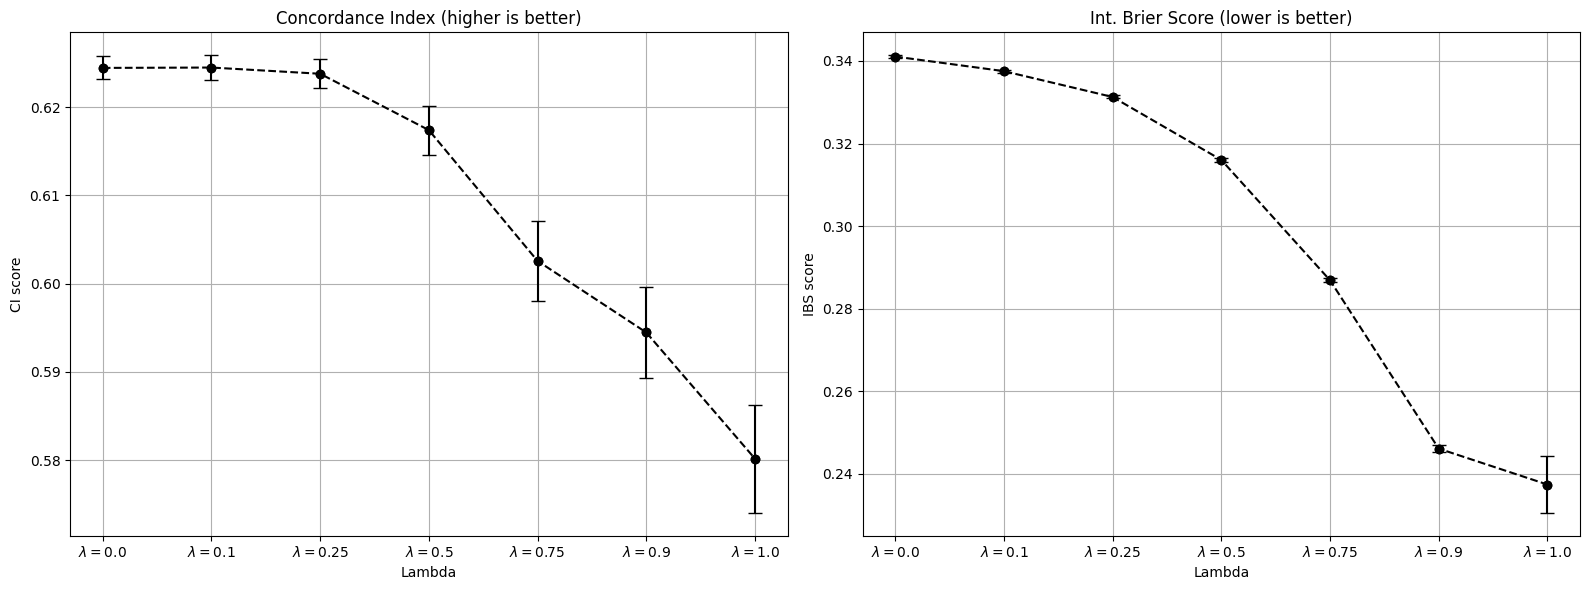

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data (replace this with your actual data)
# rw_ci_dtd = np.random.rand(5, 7)  # Example data of shape (5, 7)
arrs = [rw_ci_dtd, rw_ibs_dtd]
titles = ['Concordance Index (higher is better)', 'Int. Brier Score (lower is better)']
labels = ['CI score', 'IBS score']

# Lambda values
lambda_values = [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(16, 6))  # Create subplots with 1 row and 2 columns

for i, ax in enumerate(axs):
    # Plot error bars with caps
    arr = arrs[i]
    # Calculate mean and standard deviation
    means = np.mean(arr, axis=0)
    stds = np.std(arr, axis=0)/np.sqrt(n_folds)

    for j in range(arr.shape[1]):
        ax.errorbar(np.arange(len(lambda_values))[j], means[j], yerr=stds[j], fmt='o', color='black', capsize=5)

    # Plot mean dots connected by dashed line
    ax.plot(np.arange(len(lambda_values)), means, linestyle='--', marker='o', color='black')

    # Add labels and title
    ax.set_xlabel('Lambda')
    ax.set_ylabel(labels[i])
    ax.set_title(titles[i])

    # Set xticks
    lambda_labels = [f"$\lambda={val}$" for val in lambda_values]
    ax.set_xticks(np.arange(len(lambda_values)))
    ax.set_xticklabels(lambda_labels)

    ax.grid(True)

plt.tight_layout()
plt.savefig('ci_ibs_ablation_h30.pdf', bbox_inches='tight')
plt.show()


In [11]:
aux1 = p_vars[0]
aux1[aux1<0]

Array([], shape=(0,), dtype=float32)

<>:20: SyntaxWarning: invalid escape sequence '\l'
<>:20: SyntaxWarning: invalid escape sequence '\l'
/var/folders/3j/6pbn_5s9411218dlhx_yzrk00000gn/T/ipykernel_45791/2775967574.py:20: SyntaxWarning: invalid escape sequence '\l'
  ax.set_title(f'$\lambda = {lambda_values[i]}$')


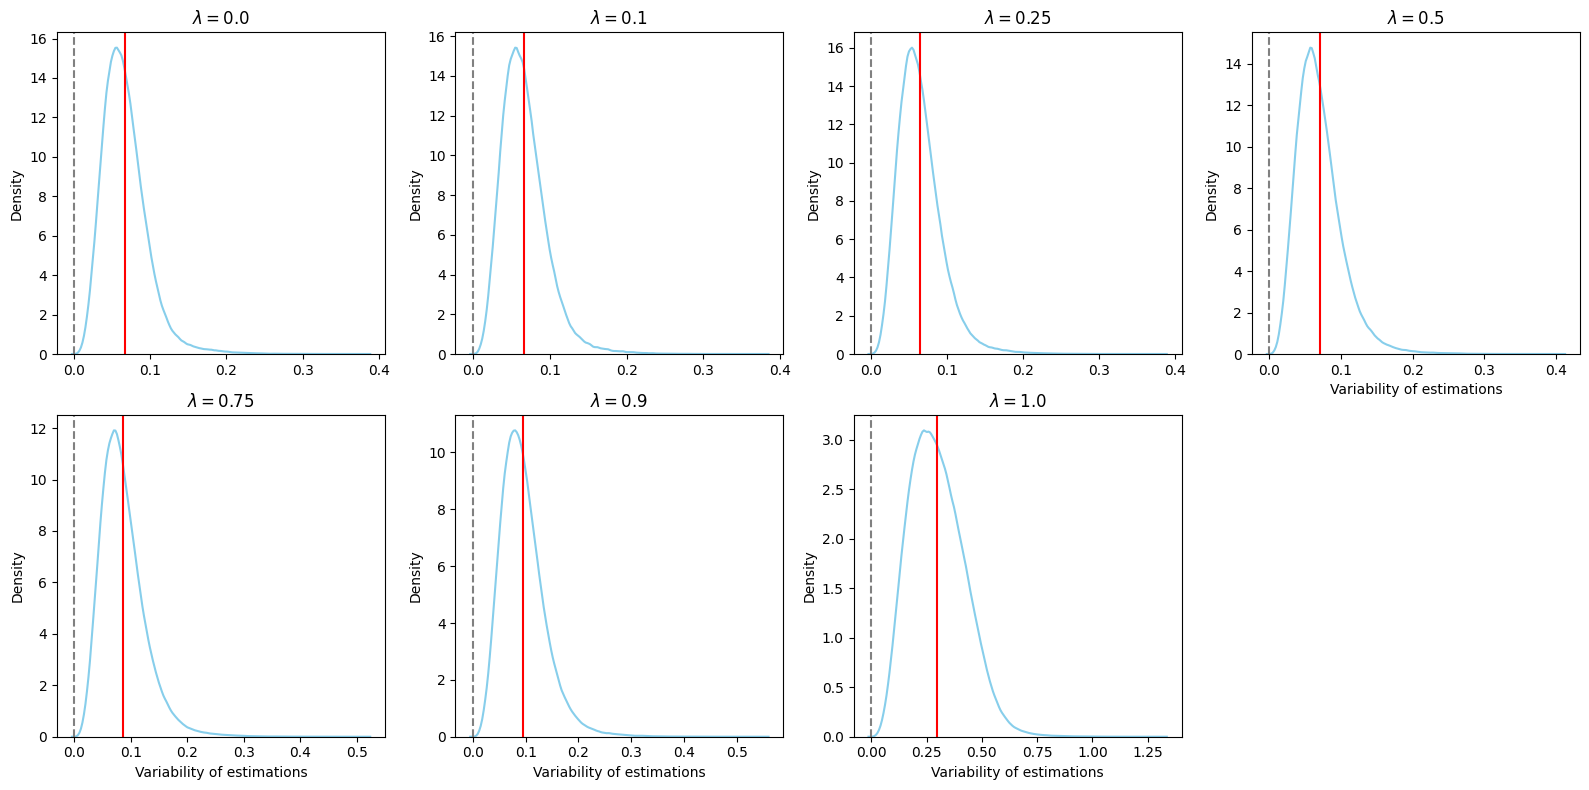

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Sample data (replace this with your actual data)
# ll = [np.random.normal(loc=i, scale=1, size=100) for i in range(7)]  # Example data
ll = p_vars

# Lambda values
lambda_values = [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]

# Plotting
fig, axs = plt.subplots(2, 4, figsize=(16, 8))  # Create subplots with 2 rows and 4 columns

for i, ax in enumerate(axs.flat):
    if i < len(ll):
        sns.kdeplot(ll[i], ax=ax, color='skyblue')
        ax.axvline(0, color='gray', linestyle='--')  # Add a gray dashed line at x=0
        ax.axvline(np.mean(ll[i]), color='red')  # Add a red vertical line at the mean
        ax.set_title(f'$\lambda = {lambda_values[i]}$')
        # Add labels selectively
        if i % 4 == 0:  # First column
            ax.set_ylabel('Density')
        if i >= 3:  # Second row
            ax.set_xlabel('Variability of estimations')
    else:
        ax.axis('off')  # Hide empty subplots

plt.tight_layout()
# plt.savefig('variability_ablation_h30.pdf', bbox_inches='tight')
plt.show()


<>:19: SyntaxWarning: invalid escape sequence '\l'
<>:19: SyntaxWarning: invalid escape sequence '\l'
/var/folders/3j/6pbn_5s9411218dlhx_yzrk00000gn/T/ipykernel_45791/3799529662.py:19: SyntaxWarning: invalid escape sequence '\l'
  ax.set_title(f'$\lambda = {lambda_values[i]}$')


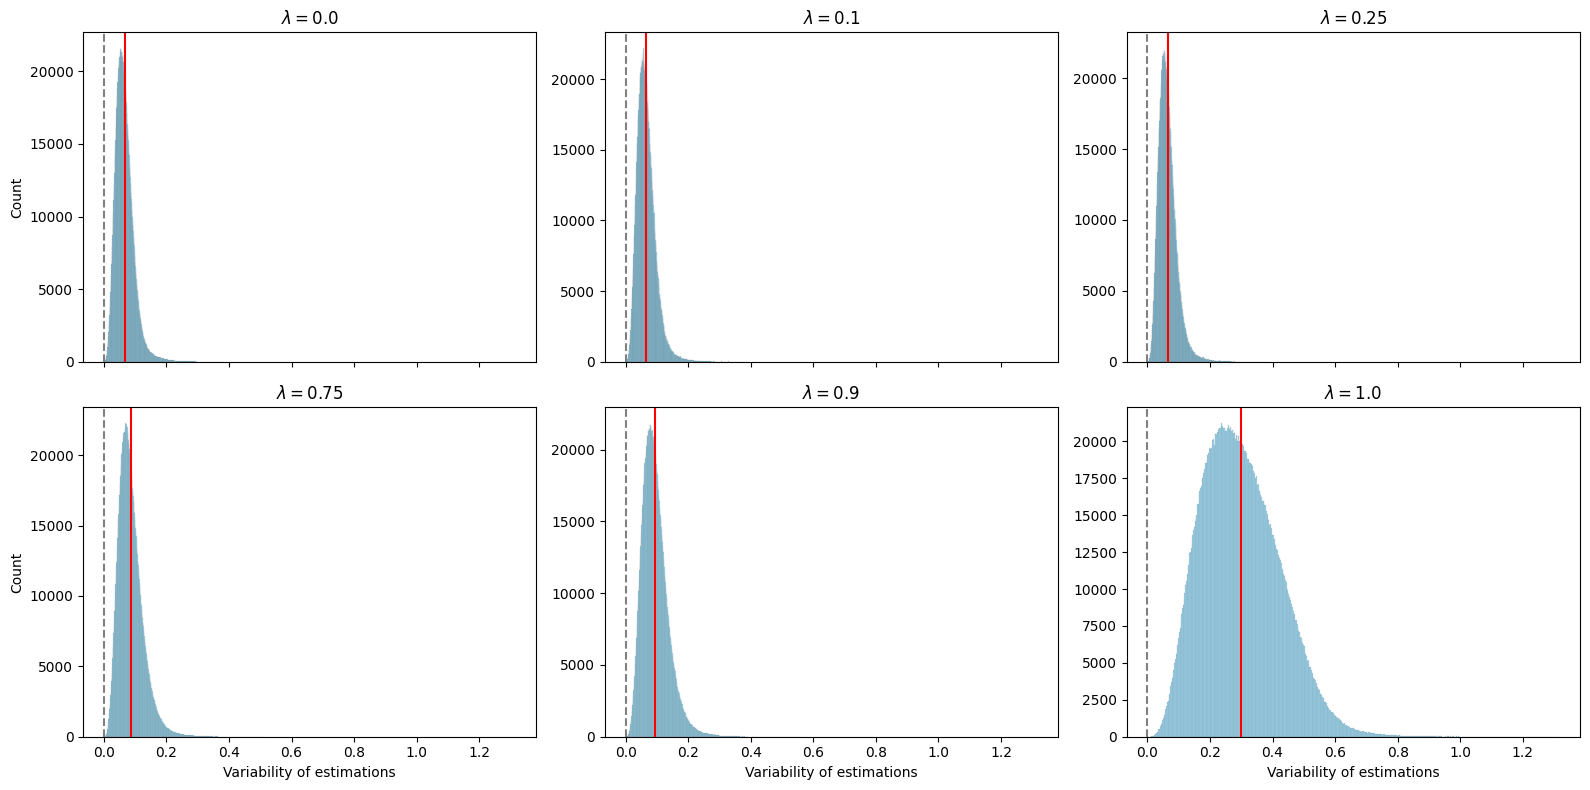

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Sample data (replace this with your actual data)
ll = [p_vars[i] for i, lambda_ in enumerate(lambdas) if lambda_ != .5]  #Removing lambda=0.5

# Lambda values
lambda_values = [0.0, 0.1, 0.25, 0.75, 0.9, 1.0]

# Plotting
fig, axs = plt.subplots(2, 3, figsize=(16, 8), sharex=True)  # Create subplots with 2 rows and 4 columns

for i, ax in enumerate(axs.flat):
    if i < len(ll):
        sns.histplot(ll[i], ax=ax, color='skyblue')  # Make histogram instead of KDE plot
        ax.axvline(0, color='gray', linestyle='--')  # Add a gray dashed line at x=0
        ax.axvline(np.mean(ll[i]), color='red')  # Add a red vertical line at the mean
        ax.set_title(f'$\lambda = {lambda_values[i]}$')
        # Add labels selectively
        if i == 0 or i == 3:  # First column
            ax.set_ylabel('Count')  # Change ylabel to 'Count' for histograms
        else:
            ax.set_ylabel('')  # Change ylabel to 'Count' for histograms
        if i < 3:
            ax.set_xlabel('')
        if i >= 2:  # Second row
            ax.set_xlabel('Variability of estimations')
    else:
        ax.axis('off')  # Hide empty subplots

plt.tight_layout()
plt.savefig('variability_ablation_h30.png', bbox_inches='tight')
plt.savefig('variability_ablation_h30.pdf', bbox_inches='tight')
plt.show()


In [113]:
data[data<0]

array([], dtype=float64)

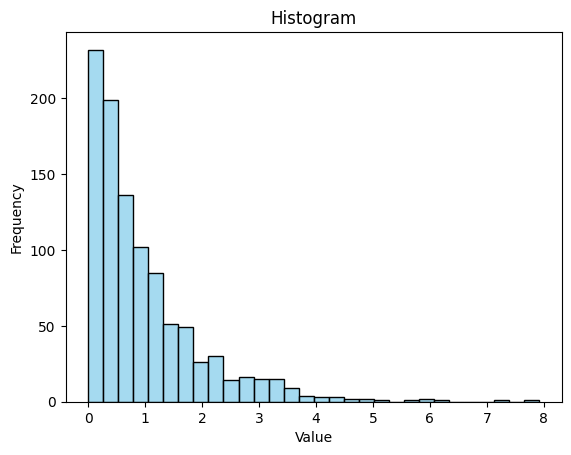

In [114]:
# Plot histogram
sns.histplot(data, kde=False, color='skyblue', bins=30)

# Add labels and title
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram')

plt.show()